Agora, com todas as informaçôes reunidas, vamos começar a análise fazendo uma organização no csv final nas categorias que vamos investigar.

In [43]:
import pandas as pd

In [44]:
df_oscar = pd.read_csv('datasets/oscar_imdb_merged.csv')
df_oscar['sexual_orientation'].value_counts(dropna=False)

sexual_orientation
Straight             433
Bisexual              21
Na                    10
Gay                    7
Matter of Dispute      3
Lesbian                2
Name: count, dtype: int64

Aqui eu vejo a quantidade total de pessoas no csv e o total de cada categoria que eu quero:

In [45]:
df_oscar['race_ethnicity'].value_counts(dropna=False)

race_ethnicity
White    442
Black     24
Asian     10
Name: count, dtype: int64

In [46]:
df_oscar.shape

(476, 35)

Agora vamos para a análise gráfica:

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

Para fazer a análise de década, garanto que "year_edition" é numérico e faço a transformação p década, ex: 2023, divido inteiramente por 10 = 202, multiplico por 10 = 2020, e a validação evita erros.

In [48]:
df = pd.read_csv('datasets/oscar_imdb_merged.csv')

df['year_edition'] = pd.to_numeric(df['year_edition'], errors='coerce').fillna(0).astype(int)

df['decade'] = (df['year_edition'] // 10) * 10
df_valid = df[df['decade'] >= 1920].copy()

Proporção racial dos vencedores por década

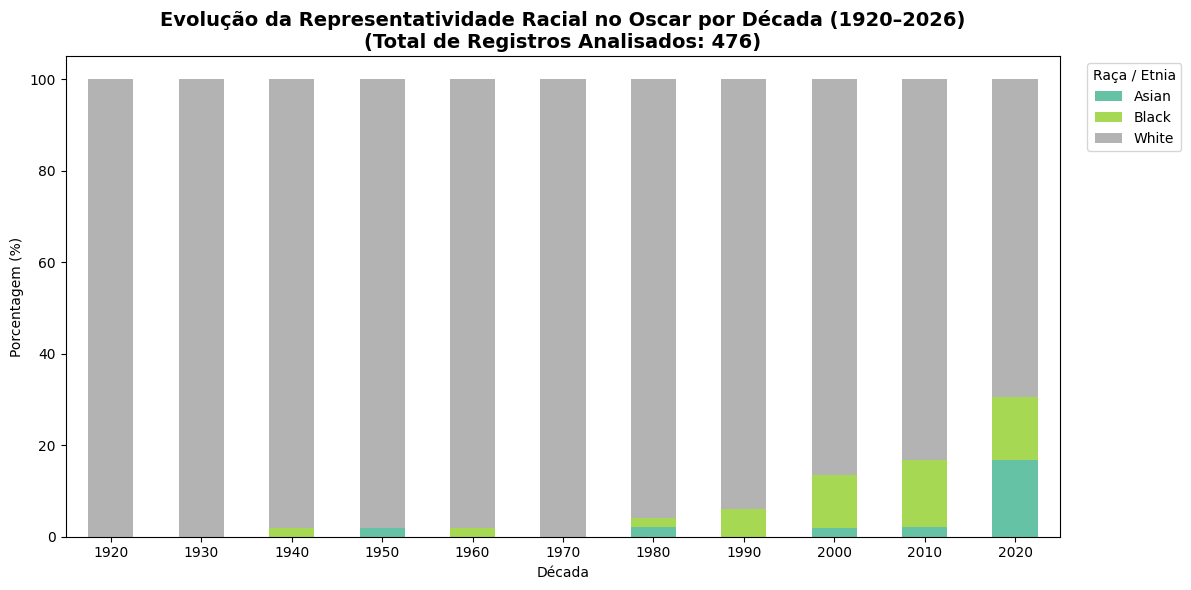

In [49]:
total = len(df_valid)

crosstab_race = pd.crosstab(df_valid['decade'], df_valid['race_ethnicity'], normalize='index') * 100

ax = crosstab_race.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title(f'Evolução da Representatividade Racial no Oscar por Década (1920–2026)\n(Total de Registros Analisados: {total})', fontsize=14, fontweight='bold')
plt.xlabel('Década')
plt.ylabel('Porcentagem (%)')
plt.legend(title='Raça / Etnia', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Distribuição da representatividade por categoria de premiação

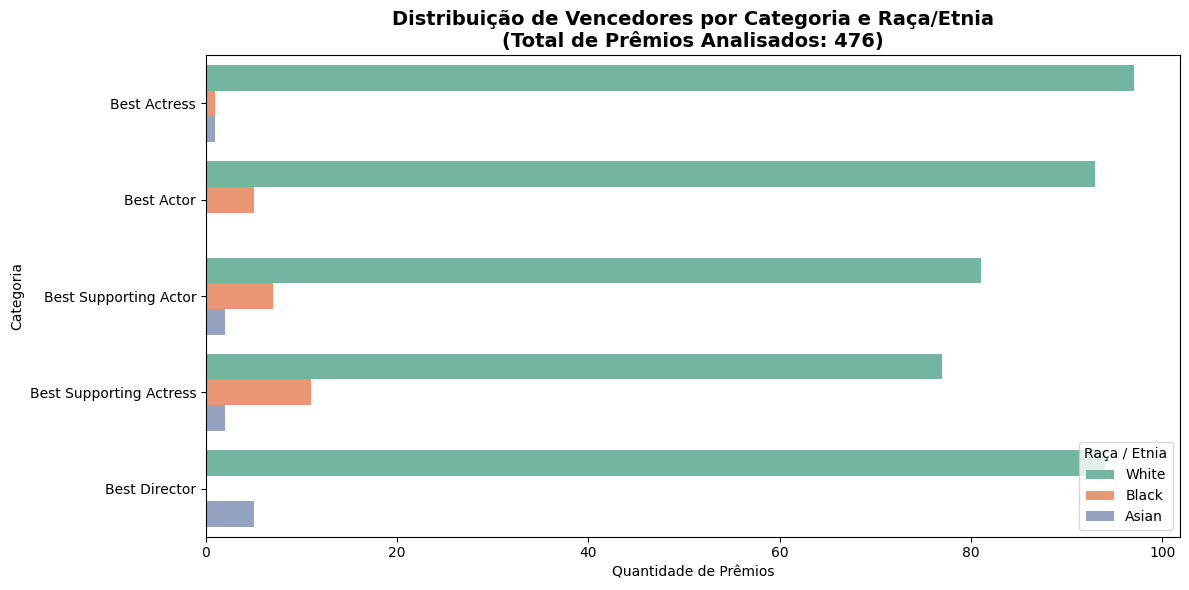

In [50]:
plt.figure(figsize=(12, 6))

sns.countplot(data=df, y='category', hue='race_ethnicity', palette='Set2')
plt.title(f'Distribuição de Vencedores por Categoria e Raça/Etnia\n(Total de Prêmios Analisados: {total})', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Prêmios')
plt.ylabel('Categoria')
plt.legend(title='Raça / Etnia', loc='lower right')
plt.tight_layout()
plt.show()